# LangGraph Basic Chatbot Learning Project
This notebook contains the complete progression of building a LangGraph chatbot, from a simple LLM wrapper to an advanced agent with tools, memory, and human-in-the-loop capabilities.

## 1. Imports & Environment Setup


In [3]:
import os
from typing import Annotated
from typing_extensions import TypedDict

# LangChain and LangGraph core components
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from langchain_community.tools import BraveSearch

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

from dotenv import load_dotenv
from IPython.display import Image, display

# Load environment variables
load_dotenv()


/var/folders/1x/f5lm3hq10391fkc1vpy_79500000gn/T/ipykernel_95530/2252773488.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import BraveSearch


True

## 2. Core State & LLM Configuration
Here we define the central state of our graph and initialize the LLM.


In [4]:
# Define the graph state. The `messages` key is a list.
# `add_messages` ensures new messages are appended to the list rather than overwriting it.
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Initialize the language model (Gemini 3.5 Flash Lite)
llm = init_chat_model(
    "gemini-3.5-flash-lite", 
    model_provider="google_genai"
)


## Part 1: The Basic Chatbot
**Purpose:** A simple graph that just passes user messages to the LLM and returns the response.


In [5]:
def basic_chatbot_node(state: State):
    """Passes the conversation history to the LLM and returns the response."""
    return {"messages": [llm.invoke(state["messages"])]}

# Build the basic graph
basic_graph_builder = StateGraph(State)
basic_graph_builder.add_node("llm_chatbot", basic_chatbot_node)
basic_graph_builder.add_edge(START, "llm_chatbot")
basic_graph_builder.add_edge("llm_chatbot", END)

# Compile into an executable graph
basic_graph = basic_graph_builder.compile()


In [6]:
# --- Testing the Basic Chatbot ---
result = basic_graph.invoke({"messages": "what day is today"})
print(result)

for step in basic_graph.stream({"messages": "i love you?"}):
    for node_output in step.values():
       print(node_output["messages"][0].content[0]["text"])


{'messages': [HumanMessage(content='what day is today', additional_kwargs={}, response_metadata={}, id='7b27b292-8fec-44b2-8743-5a829661a9e9'), AIMessage(content=[{'type': 'text', 'text': "I do not have access to real-time information, so I don't know what today's date is. Please check the date and time settings on your device.", 'extras': {'signature': 'El4KXAERTTIParVIgItpezYoZUeRy9L17VM+jaDUlmHA3xEsxozOf107DxsBCjIdwcW6vce0fP7yEck9G3lZ89RrFHwvBHrLHcMUpstmcT1dxwV7QOZrA5bwP1qAfoQm'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a00bed-bd92-7491-b467-ec2454d51c56-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 35, 'total_tokens': 40, 'input_token_details': {'cache_read': 0}})]}
Well, thank you! That's very kind of you to say. 😊 

I'm an AI, so I don't have feelings, but I *do* love helping you out, answering yo

## Part 2: The Tool-Calling Agent
**Purpose:** Give the LLM access to external tools (Search and Math) so it can answer real-time questions and perform calculations.


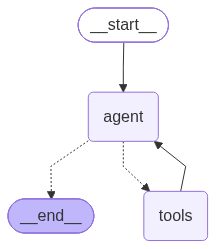

In [7]:
# 1. Define Tools
# Brave Search tool (retrieves top 5 search results)
brave_search_tool = BraveSearch.from_search_kwargs(
    search_kwargs={"count": 5}
)

@tool
def multiplier(a: int, b: int) -> int:
    """Multiply two integers together.
    
    Args:
        a (int): The first number
        b (int): The second number
        
    Returns:
        int: The product of a and b
    """
    return a * b

agent_tools = [brave_search_tool, multiplier]

# Bind the tools to the LLM so it knows they exist and how to use them
llm_with_tools = llm.bind_tools(agent_tools)

# 2. Define the Agent Node
def tool_calling_chatbot_node(state: State):
    """Invokes the LLM equipped with tools."""
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# 3. Build the Agent Graph
agent_graph_builder = StateGraph(State)
agent_graph_builder.add_node("agent", tool_calling_chatbot_node)
agent_graph_builder.add_node("tools", ToolNode(agent_tools))

# The workflow starts at the agent
agent_graph_builder.add_edge(START, "agent")

# If the agent decides to use a tool, route to "tools". Otherwise, route to END.
agent_graph_builder.add_conditional_edges(
    "agent",
    tools_condition
)

"""We don't need to explicitly route to END here 
because `tools_condition` is pre-programmed to 
automatically route to END if the LLM didn't request a tool."""


# After a tool finishes running, route back to the agent to read the tool's output
agent_graph_builder.add_edge("tools", "agent")

agent_graph = agent_graph_builder.compile()

# Display the graph
display(Image(agent_graph.get_graph().draw_mermaid_png()))


In [8]:
# --- Testing the Tool-Calling Agent ---

response = agent_graph.invoke({"messages": "give me the recent ai news and then multiply 12 by 10"})
for msg in response["messages"]:
     msg.pretty_print()


================================ Human Message =================================

give me the recent ai news and then multiply 12 by 10
================================== Ai Message ==================================

[]
Tool Calls:
  brave_search (call_2394180)
 Call ID: call_2394180
  Args:
    query: latest AI news 2026
  multiplier (call_2394181)
 Call ID: call_2394181
  Args:
    b: 10
    a: 12
================================= Tool Message =================================
Name: brave_search

[{"title": "Reuters AI News | Latest Headlines and Developments | Reuters", "link": "https://www.reuters.com/technology/artificial-intelligence/", "snippet": "July 3, 2026 \u00b7 category<strong>Alibaba, Tencent back Kuaishou&#x27;s Kling AI in $2.8 billion fundraise</strong> \u00b7 July 3, 2026 \u00b7 WorldcategoryAlibaba to ban employees from using Anthropic&#x27;s coding tool, source says \u00b7 July 3, 2026 \u00b7 BusinesscategoryGermany&#x27;s ... July 5, 2026 \u00b7 EventMomentum AI S

## Part 3: Adding Memory (Checkpointers)
**Purpose:** Allow the graph to remember past conversations by saving the state to a specific `thread_id`.


In [9]:
# Recompile the agent graph, but this time attach a MemorySaver
memory_saver = MemorySaver()
memory_graph = agent_graph_builder.compile(checkpointer=memory_saver)

# Configuration dictionary to tell the graph which conversation thread to load
thread_config = {"configurable": {"thread_id": "1"}}


In [10]:
# --- Testing Memory ---
memory_graph.invoke({"messages": "hi i am adam"}, config=thread_config)
response = memory_graph.invoke({"messages": "hi, do you remember my name?"}, config=thread_config)
print(response["messages"][-1].content[0]['text'])


Yes, you're Adam!


## Part 4: Streaming Modes Explained
**Purpose:** Demonstrate how to stream data out of the graph as it runs.
*   **Mode 1:** `"updates"` -> Yields ONLY what changed at that exact step.
*   **Mode 2:** `"values"` -> Yields the ENTIRE conversational history at each step.


In [11]:
config_stream = {"configurable": {"thread_id": "02"}}

# --- Testing Updates Mode ---
print("--- UPDATES MODE ---")
for step in memory_graph.stream({"messages": "haha, you stupid haha"}, config_stream, stream_mode="updates"):
     print(step["agent"]["messages"][0].content[0]['text'])

--- UPDATES MODE ---
Ouch, right in the silicon! 😅 

What did I mess up? Let me know and I'll try to do better!


In [12]:
# --- Testing Values Mode ---
print("--- VALUES MODE ---")
for step in memory_graph.stream({"messages": "hi"}, config_stream, stream_mode="values"):
     print(step["messages"])

--- VALUES MODE ---
[HumanMessage(content='haha, you stupid haha', additional_kwargs={}, response_metadata={}, id='37fb4b10-9362-4650-8fbe-ec7bfcd64426'), AIMessage(content=[{'type': 'text', 'text': "Ouch, right in the silicon! 😅 \n\nWhat did I mess up? Let me know and I'll try to do better!", 'extras': {'signature': 'El4KXAERTTIPOirLgsGKdCYFirww4y9As9RG0iWtTvJZ4vtAQzYhpCs/nLYQ8aM1kJubqdFGPDiBjt4WJSy9cuSzRotl4Ps8eOiPEBuAKxwrdmTTR3Yv1tPF9O8c+fUn'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a00bed-e14a-7752-b7ae-2b0476382bbf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 153, 'output_tokens': 30, 'total_tokens': 183, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='1f25dbb4-df91-4e54-b682-8fe59787a34e')]
[HumanMessage(content='haha, you stupid haha', addition

## Part 5: Human-in-the-Loop (Interrupts)
**Purpose:** Pause the graph's execution to wait for human approval or input before continuing.


In [13]:
@tool
def human_assistance(query: str) -> str:
    """Request assistance or guidance from a human expert."""
    # The graph will pause here and wait for a user to provide the "data"
    human_response = interrupt({"query": query})
    return human_response["data"]

# Setup tools for the human-in-the-loop graph
hitl_tools = [human_assistance, brave_search_tool]
llm_with_hitl_tools = llm.bind_tools(hitl_tools)

def hitl_chatbot_node(state: State):
    """Invokes the LLM. Parallel tool calling is disabled during human interrupts to avoid duplicate calls."""
    message = llm_with_hitl_tools.invoke(state["messages"])
    return {"messages": message}

# Build the Human-in-the-Loop Graph
hitl_graph_builder = StateGraph(State)
hitl_graph_builder.add_node("chatbot", hitl_chatbot_node)
hitl_graph_builder.add_node("tools", ToolNode(tools=hitl_tools))

hitl_graph_builder.add_edge(START, "chatbot")
hitl_graph_builder.add_conditional_edges("chatbot", tools_condition)
hitl_graph_builder.add_edge("tools", "chatbot")

# Compile with memory (Memory is REQUIRED for interrupts so the graph can resume where it left off)
hitl_memory = MemorySaver()
hitl_graph = hitl_graph_builder.compile(checkpointer=hitl_memory)


In [21]:
# --- Testing Human-in-the-Loop ---
config_hitl = {"configurable": {"thread_id": "04"}}
user_input = "i need some expert guidince and assistance for building an AI agent. could you request assitance for me"
#
# # 1. Start the graph (It will pause when the tool calls `interrupt`)
for step in hitl_graph.stream({"messages": user_input}, config_hitl, stream_mode="values"):
     step["messages"][-1].pretty_print()


================================ Human Message =================================

i need some expert guidince and assistance for building an AI agent. could you request assitance for me
================================== Ai Message ==================================

[]
Tool Calls:
  human_assistance (call_2768250)
 Call ID: call_2768250
  Args:
    query: User needs expert guidance and assistance for building an AI agent. Connecting with a human expert or setting up a structured assistance framework.
================================== Ai Message ==================================

[]
Tool Calls:
  human_assistance (call_2768250)
 Call ID: call_2768250
  Args:
    query: User needs expert guidance and assistance for building an AI agent. Connecting with a human expert or setting up a structured assistance framework.


In [22]:
# # 2. The human provides their response
human_reply = {
    "data": (
         "We, the experts are here to help! "
         "We'd recommend you check out LangGraph to build your agent. "
         "It's much more reliable and extensible than simple autonomous agents."
     )
              }
#
# # 3. Resume the graph using the Command object
for step in hitl_graph.stream(Command(resume=human_reply), config_hitl, stream_mode="values"):
     step["messages"][-1].pretty_print()

================================== Ai Message ==================================

[]
Tool Calls:
  human_assistance (call_2768250)
 Call ID: call_2768250
  Args:
    query: User needs expert guidance and assistance for building an AI agent. Connecting with a human expert or setting up a structured assistance framework.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

[{'type': 'text', 'text': "Building an AI agent can be an exciting project, and we have some expert guidance to help you get started on the right foot! \n\nOur recommendation from the engineering experts is to check out **LangGraph** (by LangChain). \n\nCompared to simple autonomous loop agents (like basic AutoGPT-style script